# Approximating the reverse causal cone with a Tree Tensor Network

For a depth-$p$ QAOA circuit, $\langle Z_iZ_j\rangle$ for an edge $(i,j)$ only depends on its **reverse causal cone**: the sub-circuit built from graph edges within distance $p$ of $i$ or $j$ (this is what `LightConeEvaluator` already exploits, via exact statevector simulation of the reduced circuit).

**Key fact**: if the graph's girth is large enough relative to $p$, this causal-cone subgraph is itself a *tree*. It can then be represented directly as a Tree Tensor Network (TTN) whose topology matches the causal cone -- every QAOA gate acts on tree-adjacent qubits, so no SWAP routing is needed. Bounding the TTN bond dimension $\chi$ gives a controlled approximation of $\langle Z_iZ_j\rangle$.

We use [pytreenet](https://github.com/Udhaya2/pytreenet)'s low-level TTN primitives (`contract_nodes` + `absorb_into_open_legs` + `split_node_svd`), the same building blocks pytreenet's own TEBD implementation uses to apply a two-site gate and truncate back down.

In [15]:
import networkx as nx
import numpy as np
import pytreenet as ptn
from scipy.linalg import expm
import time

from qaoa_training_pipeline.evaluation.light_cone import LightConeEvaluator
from qaoa_training_pipeline.evaluation.mps_evaluator import MPSEvaluator
from qaoa_training_pipeline.evaluation.efficient_depth_one import EfficientDepthOneEvaluator
from qaoa_training_pipeline.utils.graph_utils import graph_to_operator, operator_to_graph

X, _, Z = ptn.pauli_matrices()

## TTN causal-cone evaluator

`causal_cone_energy` builds the causal-cone tree of a single edge (reusing `LightConeEvaluator.make_radius_edges`), represents it as a `|+>`-product TTN, applies the QAOA layers as tree-local RZZ/RX gates with bond dimension `max_bond_dim`, and reads off `<Z_iZ_j>`. `ttn_causal_cone_evaluate` sums this over all edges to get the QAOA energy.

In [2]:
def causal_cone_energy(graph, edge, betas, gammas, max_bond_dim):
    """<Z_i Z_j> for `edge`, approximated via a bond-dimension-limited TTN of its causal cone."""
    lce = LightConeEvaluator()
    lce.graph = graph
    depth = len(betas)
    cone_edges = lce.make_radius_edges(edge, radius=depth)

    tree = nx.Graph()
    tree.add_edges_from((u, v, {"weight": w}) for (u, v), w in cone_edges.items())
    if not tree.has_edge(*edge):
        tree.add_edge(*edge, weight=graph[edge[0]][edge[1]].get("weight", 1.0))
    if not nx.is_tree(tree):
        # Cone has a cycle (graph girth too small for this depth): fall back to
        # LightConeEvaluator's exact statevector simulation for just this edge.
        circ, obs = lce.make_radius_circuit(edge, list(betas) + list(gammas))
        circ = circ.decompose()
        result = lce.primitive.run([(circ, obs)]).result()
        return float(np.real(result[0].data.evs))

    # Build a |+>-product TTN whose topology is exactly the causal-cone tree.
    root = edge[0]
    degree = dict(tree.degree)
    plus_tensor = lambda n_neighbours: np.full((1,) * n_neighbours + (2,), 1 / np.sqrt(2), dtype=complex)

    ttn = ptn.TreeTensorNetworkState()
    ttn.add_root(ptn.Node(identifier=str(root)), plus_tensor(degree[root]))
    next_free_slot = {root: 0}  # next unused neighbour-leg on each node already in the TTN
    for parent, child in nx.bfs_edges(tree, root):
        ttn.add_child_to_parent(
            ptn.Node(identifier=str(child)), plus_tensor(degree[child]),
            0, str(parent), next_free_slot[parent],
        )
        next_free_slot[parent] += 1
        next_free_slot[child] = 1  # leg 0 of the child is now taken by its parent

    svd_params = ptn.SVDParameters(max_bond_dim=max_bond_dim, rel_tol=0.0, total_tol=1e-14)

    def apply_two_site_gate(id1, id2, gate):
        # Same 4-step pattern pytreenet's TEBD uses to apply+truncate a nearest-neighbour gate.
        u_legs, v_legs = ttn.legs_before_combination(id1, id2)
        ttn.contract_nodes(id1, id2, new_identifier="contr")
        ttn.absorb_into_open_legs("contr", gate)
        ttn.split_node_svd("contr", u_legs, v_legs, u_identifier=id1, v_identifier=id2, svd_params=svd_params)

    for beta, gamma in zip(betas, gammas):
        for u, v, w in tree.edges(data="weight"):
            rzz = expm(-1j * gamma * w * np.kron(Z, Z)).reshape(2, 2, 2, 2)
            apply_two_site_gate(str(u), str(v), rzz)
        for node in tree.nodes:
            ttn.absorb_into_open_legs(str(node), expm(-1j * beta * X))

    zz = ttn.operator_expectation_value(ptn.TensorProduct({str(edge[0]): Z, str(edge[1]): Z}))
    return float(np.real(zz / ttn.scalar_product()))  # renormalize away any truncation-induced norm drift


def ttn_causal_cone_evaluate(cost_op, params, max_bond_dim):
    """QAOA energy as a sum of TTN-approximated causal-cone edge expectation values."""
    depth = len(params) // 2
    betas, gammas = params[:depth], params[depth:]
    graph = operator_to_graph(cost_op)
    return sum(
        w * causal_cone_energy(graph, (u, v), betas, gammas, max_bond_dim)
        for u, v, w in graph.edges(data="weight")
    )

## Validation against exact statevector simulation

We use the McGee graph (girth 7, cubic, 24 nodes), so that every edge's depth-2 causal cone is guaranteed to be a tree.

In [ ]:
# mcgee_graph = nx.LCF_graph(24, [12, 7, -7], 8)
mcgee_graph = nx.random_regular_graph(5, 100)
cost_op = graph_to_operator(mcgee_graph, pre_factor=-0.5)  # standard MaxCut convention

rng = np.random.default_rng(0)
depth = 1
params = rng.uniform(-1, 1, size=2 * depth)  # [beta_0, ..., beta_{p-1}, gamma_0, ..., gamma_{p-1}]

# exact_energy = StatevectorEvaluator().evaluate(cost_op, list(params))
t_mps = time.time()
mps_energy = MPSEvaluator(bond_dim_circuit=32, use_swap_strategy=True).evaluate(cost_op, params)
t_ttn = time.time()
ttn_energy = ttn_causal_cone_evaluate(cost_op, params, max_bond_dim=32)
t_eff_depth_1 = time.time()
eff_depth_one = EfficientDepthOneEvaluator().evaluate(cost_op, params)
# print(f"exact statevector energy:  {exact_energy:.10f}")
print(f"TTN causal-cone energy:    {ttn_energy:.10f}")
print(f"MPS evaluator energy:    {mps_energy:.10f}")
print(f"Efficient depth one evaluator energy:    {eff_depth_one:.10f}")

print(f"TTN causal-cone energy:    {time.time() - t_ttn}")
print(f"MPS evaluator energy:    {time.time() - t_mps}")
print(f"Efficient depth one evaluator energy:    {time.time() - t_eff_depth_1}")

TTN causal-cone energy:    -32.2282839770
MPS evaluator energy:    -10.9993080210
Efficient depth one evaluator energy:    -32.2282839770


## Effect of the bond dimension

At fixed depth, the causal cone's entanglement is bounded, so the TTN energy converges to the exact value once `max_bond_dim` is large enough -- this is the accuracy/cost knob for larger, deeper causal cones where exact simulation is not an option.

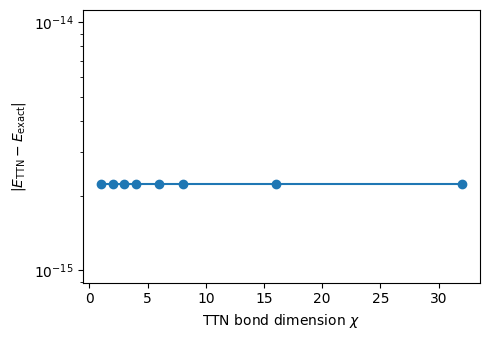

In [4]:
bond_dimensions = [1, 2, 3, 4, 6, 8, 16, 32]
errors = [abs(ttn_causal_cone_evaluate(cost_op, params, chi) - exact_energy) for chi in bond_dimensions]

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(bond_dimensions, np.maximum(errors, 1e-16), "o-")
ax.set_xlabel(r"TTN bond dimension $\chi$")
ax.set_ylabel(r"$|E_{\mathrm{TTN}} - E_{\mathrm{exact}}|$")
ax.set_yscale("log")
fig.tight_layout()